# Notebook 02_01
## REINFORCE na CartPole (stan = wektor liczb) 🎯

Ten notebook jest **mostem** między:
- **01 (DQN)**: uczymy $Q_\theta(s,a)$ (value-based)
- **01 (DQN pixels)**: stan staje się obrazem → jeszcze większa potrzeba dobrej reprezentacji

Tutaj przechodzimy na drugą rodzinę metod:
### **policy-based**: uczymy bezpośrednio politykę $\pi_\theta(a\mid s)$.

---
## Co ma „kliknąć” dydaktycznie
1. **W 02/DQN**: uczymy wartość akcji i wybieramy akcję przez argmax.
2. **W REINFORCE**: uczymy rozkład prawdopodobieństwa akcji i **losujemy akcje** z $\pi_\theta$.
3. REINFORCE jest czyste koncepcyjnie, ale ma **dużą wariancję** → baseline/advantage jako naturalny upgrade.


## 1) Teoria: co optymalizujemy?

Chcemy maksymalizować oczekiwany zwrot:
$$
J(\theta)=\mathbb{E}_{\tau\sim \pi_\theta}\,[G_0]
$$
gdzie trajektoria $\tau=(s_0,a_0,r_0,\dots)$.

**Twierdzenie policy gradient** daje:
$$
\nabla_\theta J(\theta)=\mathbb{E}\left[\sum_t \nabla_\theta \log \pi_\theta(a_t\mid s_t)\,G_t\right].
$$

### Co to znaczy intuicyjnie?
- jeśli epizod wyszedł dobrze (duży $G_t$), to zwiększamy prawdopodobieństwa akcji, które rzeczywiście wykonaliśmy,
- jeśli wyszedł źle, to je zmniejszamy.

### Problem
$G_t$ jest Monte Carlo → **szum / wariancja**.

### Baseline (prawie zawsze potrzebny)
Możemy odjąć dowolny baseline niezależny od akcji (np. $b(s)=V_\phi(s)$):
$$
\nabla_\theta J(\theta)=\mathbb{E}\left[\sum_t \nabla_\theta \log \pi_\theta(a_t\mid s_t)\,(G_t-b(s_t))\right].
$$
To nie zmienia wartości oczekiwanej gradientu, ale **mocno redukuje wariancję**.


## 2) Schemat przepływu (warto to pokazać na zajęciach)

**Value-based (DQN)**
```
s  ->  Qθ(s,·)  ->  argmax  ->  a  ->  env  ->  (r,s')
             ^                 |
             |----- TD target -|
```

**Policy-based (REINFORCE)**
```
s  ->  πθ(·|s)  ->  sample  ->  a  ->  env  ->  (r,s')
             ^
             |--- reinforce with Gt / (Gt - baseline)
```

REINFORCE nie potrzebuje "max" ani target network, ale płaci za to wariancją.


In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym


# --- device (jak u Ciebie) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


# --- reproducibility ---
def seed_everything(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# --- env wrappers (jak w Ch01) ---
def make_env(env_id="CartPole-v1", seed=0, render=False):
    env = gym.make(env_id, render_mode=("human" if render else None))
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env

def reset_env(env, seed=None):
    obs, _ = env.reset(seed=seed)
    return obs

def step_env(env, action):
    obs2, r, terminated, truncated, _ = env.step(int(action))
    done = bool(terminated or truncated)
    return obs2, float(r), done


# --- evaluation (jak w Ch01): policy_fn(obs)->action(int) ---
def evaluate_policy(env_id, policy_fn, episodes=20, seed=123):
    env = make_env(env_id, seed=seed, render=False)
    rets = []
    for k in range(episodes):
        obs = reset_env(env, seed=seed + k)
        done = False
        ep_ret = 0.0
        while not done:
            a = int(policy_fn(obs))
            obs, r, done = step_env(env, a)
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def moving_average(x, w=50):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")


device = cpu


In [2]:
import os
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Gymnasium (preferowane). Jeśli masz tylko gym, to fallback.
try:
    import gymnasium as gym
    GYMNASIUM = True
except Exception:
    import gym
    GYMNASIUM = False

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '| gymnasium:', GYMNASIUM)


device: cpu | gymnasium: True


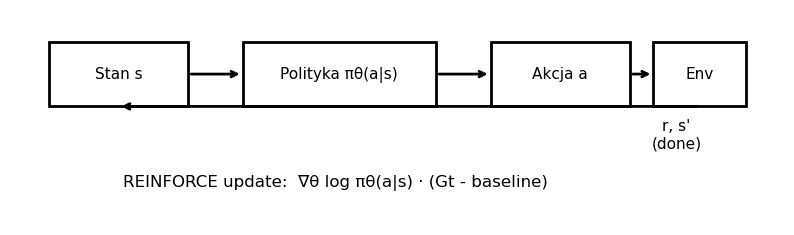

In [3]:
# (opcjonalne) mały rysunek-schemat do slajdów / intuicji
def draw_rl_schematic():
    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis('off')

    def box(x, y, w, h, text):
        ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, linewidth=2))
        ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=11)

    box(0.05, 0.55, 0.18, 0.3, 'Stan s')
    box(0.30, 0.55, 0.25, 0.3, 'Polityka πθ(a|s)')
    box(0.62, 0.55, 0.18, 0.3, 'Akcja a')
    box(0.83, 0.55, 0.12, 0.3, 'Env')

    ax.annotate('', xy=(0.30, 0.70), xytext=(0.23, 0.70), arrowprops=dict(arrowstyle='->', lw=2))
    ax.annotate('', xy=(0.62, 0.70), xytext=(0.55, 0.70), arrowprops=dict(arrowstyle='->', lw=2))
    ax.annotate('', xy=(0.83, 0.70), xytext=(0.80, 0.70), arrowprops=dict(arrowstyle='->', lw=2))

    ax.text(0.86, 0.42, 'r, s\'\n(done)', ha='center', va='center', fontsize=11)
    ax.annotate('', xy=(0.14, 0.55), xytext=(0.89, 0.55), arrowprops=dict(arrowstyle='->', lw=2))

    ax.text(0.42, 0.18, 'REINFORCE update:  ∇θ log πθ(a|s) · (Gt - baseline)', ha='center', fontsize=12)
    plt.show()

draw_rl_schematic()


In [4]:
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, hidden=128, act_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, act_dim)
        )

    def forward(self, x):
        return self.net(x)  # logits


class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # (batch,)


## 3) Implementacja: REINFORCE (bez baseline) i REINFORCE + baseline

Zrobimy dwie wersje:
1. **REINFORCE**: update z samym $G_t$
2. **REINFORCE + baseline**: update z przewagą $A_t = G_t - V_\phi(s_t)$

Porównamy stabilność na wykresach.


In [5]:
def compute_returns(rewards, gamma):
    G = 0.0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return np.array(returns, dtype=np.float32)


In [6]:
def train_reinforce(
    seed=0,
    episodes=800,
    gamma=0.99,
    lr_pi=1e-3,
    lr_v=1e-3,
    use_baseline=True,
    hidden=128,
    max_steps=500,
):
    # --- env ---
    if GYMNASIUM:
        env = gym.make('CartPole-v1')
        env.reset(seed=seed)
        env.action_space.seed(seed)
    else:
        env = gym.make('CartPole-v1')
        try:
            env.seed(seed)
        except Exception:
            pass

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    pi = PolicyNet(obs_dim, hidden=hidden, act_dim=act_dim).to(device)
    opt_pi = optim.Adam(pi.parameters(), lr=lr_pi)

    if use_baseline:
        v = ValueNet(obs_dim, hidden=hidden).to(device)
        opt_v = optim.Adam(v.parameters(), lr=lr_v)
    else:
        v, opt_v = None, None

    stats = {
        'episode_return': [],
        'episode_len': [],
        'policy_loss': [],
        'value_loss': [],
        'use_baseline': use_baseline,
        'seed': seed,
        'gamma': gamma,
        'lr_pi': lr_pi,
        'lr_v': lr_v,
        'hidden': hidden,
    }

    for ep in range(episodes):
        # --- rollout ---
        if GYMNASIUM:
            obs, _ = env.reset()
        else:
            obs = env.reset()

        logps = []
        values = []
        rewards = []
        ep_return = 0.0
        ep_len = 0

        for t in range(max_steps):
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device)
            logits = pi(obs_t)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            logp = dist.log_prob(action)

            if use_baseline:
                val = v(obs_t)
                values.append(val)

            logps.append(logp)

            if GYMNASIUM:
                next_obs, reward, terminated, truncated, _ = env.step(int(action.item()))
                done = terminated or truncated
            else:
                next_obs, reward, done, _ = env.step(int(action.item()))

            rewards.append(float(reward))
            ep_return += float(reward)
            ep_len += 1
            obs = next_obs
            if done:
                break

        # --- compute returns ---
        returns = compute_returns(rewards, gamma)
        returns_t = torch.tensor(returns, dtype=torch.float32, device=device)

        logps_t = torch.stack(logps)  # (T,)

        if use_baseline:
            values_t = torch.stack(values)  # (T,)
            # advantage
            adv_t = returns_t - values_t.detach()
        else:
            adv_t = returns_t

        # --- policy update ---
        policy_loss = -(logps_t * adv_t).mean()
        opt_pi.zero_grad()
        policy_loss.backward()
        nn.utils.clip_grad_norm_(pi.parameters(), max_norm=1.0)
        opt_pi.step()

        # --- value update (baseline) ---
        value_loss = torch.tensor(0.0, device=device)
        if use_baseline:
            value_loss = ((values_t - returns_t) ** 2).mean()
            opt_v.zero_grad()
            value_loss.backward()
            nn.utils.clip_grad_norm_(v.parameters(), max_norm=1.0)
            opt_v.step()

        # --- log stats ---
        stats['episode_return'].append(ep_return)
        stats['episode_len'].append(ep_len)
        stats['policy_loss'].append(float(policy_loss.detach().cpu()))
        stats['value_loss'].append(float(value_loss.detach().cpu()))

        if (ep + 1) % 50 == 0:
            avg100 = np.mean(stats['episode_return'][-100:])
            print(f"ep {ep+1:4d} | avg_return(last100)={avg100:6.1f} | len={ep_len:3d}")

    env.close()
    return stats


## 4) Uruchomienie: porównanie dwóch wariantów

Zrobimy dwa treningi:
- REINFORCE **bez baseline** (wysoka wariancja)
- REINFORCE **z baseline** (zwykle stabilniej)

Jeśli chcesz szybciej: zmniejsz `episodes` do 300–500.


In [7]:
stats_nobase = train_reinforce(use_baseline=False, episodes=600, seed=0)
stats_base   = train_reinforce(use_baseline=True,  episodes=600, seed=0)


ep   50 | avg_return(last100)=  12.8 | len= 13
ep  100 | avg_return(last100)=  15.6 | len= 34
ep  150 | avg_return(last100)=  20.7 | len= 26
ep  200 | avg_return(last100)=  40.5 | len= 86
ep  250 | avg_return(last100)=  74.5 | len= 56
ep  300 | avg_return(last100)=  73.1 | len= 41
ep  350 | avg_return(last100)=  46.8 | len= 48
ep  400 | avg_return(last100)=  43.7 | len= 34
ep  450 | avg_return(last100)=  47.1 | len= 92
ep  500 | avg_return(last100)=  54.1 | len= 42
ep  550 | avg_return(last100)=  62.0 | len= 40
ep  600 | avg_return(last100)=  73.2 | len=104
ep   50 | avg_return(last100)=  35.5 | len= 60
ep  100 | avg_return(last100)=  70.9 | len=202
ep  150 | avg_return(last100)= 145.0 | len=136
ep  200 | avg_return(last100)= 152.3 | len=212
ep  250 | avg_return(last100)= 120.4 | len=115
ep  300 | avg_return(last100)= 136.3 | len=173
ep  350 | avg_return(last100)= 291.9 | len=466
ep  400 | avg_return(last100)= 334.7 | len=193
ep  450 | avg_return(last100)= 320.4 | len=500
ep  500 | avg

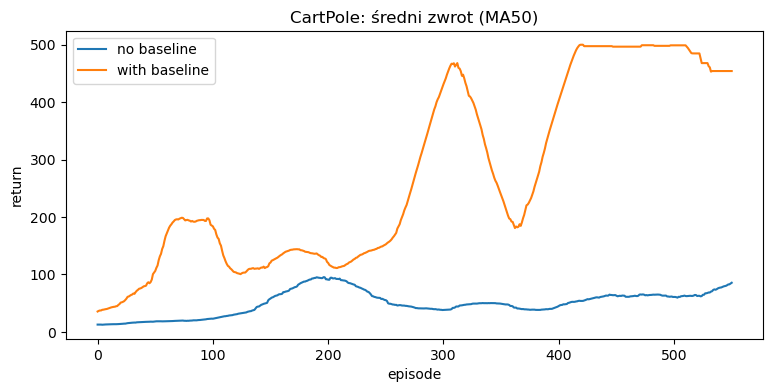

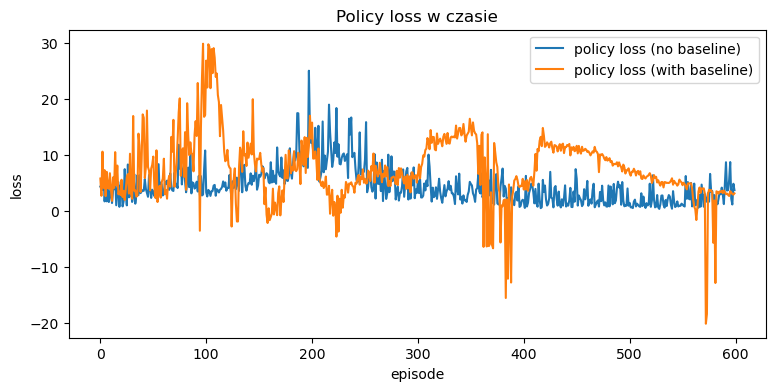

In [8]:
def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.figure(figsize=(9,4))
for label, st in [('no baseline', stats_nobase), ('with baseline', stats_base)]:
    r = st['episode_return']
    ma = moving_average(r, 50)
    plt.plot(ma, label=label)
plt.title('CartPole: średni zwrot (MA50)')
plt.xlabel('episode')
plt.ylabel('return')
plt.legend()
plt.show()

plt.figure(figsize=(9,4))
plt.plot(stats_nobase['policy_loss'], label='policy loss (no baseline)')
plt.plot(stats_base['policy_loss'], label='policy loss (with baseline)')
plt.title('Policy loss w czasie')
plt.xlabel('episode')
plt.ylabel('loss')
plt.legend()
plt.show()


## 5) Co obserwować

1. **Bez baseline** krzywa zwrotu zwykle jest bardziej „szarpana” (wariancja gradientu).
2. **Z baseline** uczenie często jest stabilniejsze i szybciej rośnie średni zwrot.

To jest dokładnie ten sam motyw co w DQN:
- w DQN stabilizujemy uczenie przez replay buffer i target network,
- w policy gradient stabilizujemy przez **baseline / advantage**.


## 6) (Stare) Zapis statystyk (spójnie z notebookami 01/02/03)

Zapiszemy do folderu `reinforce_cartpole/checkpoints/` plik `training_stats.json`.


In [9]:
out_dir = Path('reinforce_cartpole/checkpoints')
out_dir.mkdir(parents=True, exist_ok=True)

payload = {
    'no_baseline': stats_nobase,
    'with_baseline': stats_base,
}
(out_dir / 'training_stats.json').write_text(json.dumps(payload, indent=2))
print('Saved:', (out_dir / 'training_stats.json').resolve())


Saved: /home/piotr/Documents/zajecia/RL/CS-RL/sutton_barto_classes/versions/RL_FrozenLake_Course_Pack_PL_v3/RL_FrozenLake_Course_Pack_PL/block2_policy_based/deeplizard_dqn_projects_with_notebooks_fixed_valid_v2/notebooks/reinforce_cartpole/checkpoints/training_stats.json


## 7) (Stare/Nowe) Jak to dopasować do Notebook 03 (pixels)

Notebook 03 robi DQN, ale stanem jest obraz → potrzebujesz:
- dużo więcej danych,
- stabilizacji (replay/target),
- sensownego przetwarzania obserwacji (render + preproc).

**Kontrast dydaktyczny:**
- REINFORCE uczy politykę bezpośrednio, ale ma wariancję.
- DQN uczy wartość akcji, ale walczy z niestabilnością przez target/replay.

To prowadzi naturalnie do actor-critic (połączenie obu światów) i dalej do PPO.
